In [1]:
from __future__ import annotations

from pathlib import Path

from qsim.pulse.visualize import (
    auto_fold_long_pulses,
    make_timing_theme,
    plot_pulses,
    pulse_ir_from_qasm,
    reorder_xy_z_channels,
)


def _write_case_inputs(case_dir: Path, qasm_text: str, backend_yaml_text: str) -> tuple[Path, Path]:
    qasm_path = case_dir / "input.qasm"
    backend_path = case_dir / "backend.yaml"
    qasm_path.write_text(qasm_text, encoding="utf-8")
    backend_path.write_text(backend_yaml_text, encoding="utf-8")
    return qasm_path, backend_path



def _backend_yaml() -> str:
    return """level: qubit
noise: deterministic
solver: se
analysis_pipeline: default
seed: 1234
"""

def generate_case(case_name: str, qasm_text: str, out_dir: Path) -> None:
    case_dir = out_dir / case_name
    case_dir.mkdir(parents=True, exist_ok=True)
    qasm_path, backend_path = _write_case_inputs(case_dir, qasm_text, _backend_yaml())

    pulse_ir = pulse_ir_from_qasm(
        qasm_path.read_text(encoding="utf-8"),
        backend_config=backend_path,
        hardware={
            "xy_freq_hz": 5.0e9,
            "ro_freq_hz": 8.0e9,
            "gate_duration": 20.0,
            "measure_duration": 2000.0,
        },
        schedule_policy='parallel',
    )
    pulse_ir = reorder_xy_z_channels(pulse_ir)
    breaks = auto_fold_long_pulses(
        pulse_ir,
        channel_prefixes=("RO",),
        min_pulse_ns=1000.0,
        keep_head_ns=40.0,
        keep_tail_ns=40.0,
    )

    timing_theme = make_timing_theme(break_display_gap_ns=16.0)

    png_path = case_dir / "timing_python.png"
    dxf_path = case_dir / "timing_diagram.dxf"
    metadata_path = case_dir / "pulse_metadata.json"
    plot_pulses(
        pulse_ir,
        timing_layout=True,
        title=case_name,
        show_clock=True,
        breaks=breaks,
        carrier_plot_max_hz=0.5e9,
        dxf_path=dxf_path,
        png_path=png_path,
        theme=timing_theme,
        pulse_metadata_path=metadata_path,
        target_ticks=20,
        XYZ_line_combine=True,
    )

    print(f"[OK] {case_name}")
    print(f"  qasm:        {qasm_path}")
    print(f"  backend:     {backend_path}")
    print(f"  python plot: {png_path}")
    print(f"  dxf:         {dxf_path}")
    print(f"  pulses json: {metadata_path}")



In [4]:
qasm_text

'OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[8] m1;\nbit[9] m2;\nqubit[17] q;\nh q[1];\ncz q[1], q[2];\ncz q[1], q[0];\nh q[0];\nh q[1];\nh q[2];\nh q[4];\nh q[5];\nh q[6];\ncz q[6], q[5];\ncz q[2], q[5];\nh q[2];\nh q[6];\nh q[7];\ncz q[7], q[8];\ncz q[7], q[6];\ncz q[7], q[3];\nh q[3];\ncz q[7], q[2];\nh q[7];\nh q[8];\nh q[9];\nh q[10];\nh q[11];\ncz q[11], q[10];\ncz q[4], q[10];\ncz q[4], q[5];\ncz q[0], q[5];\nh q[0];\nh q[4];\nh q[5];\nh q[10];\nh q[11];\nh q[12];\ncz q[12], q[13];\ncz q[12], q[11];\ncz q[12], q[6];\nh q[6];\ncz q[12], q[4];\nh q[12];\nh q[13];\nh q[14];\nh q[15];\ncz q[15], q[14];\ncz q[8], q[14];\ncz q[8], q[9];\ncz q[3], q[9];\nh q[3];\nh q[8];\nh q[9];\ncz q[13], q[14];\ncz q[6], q[14];\nh q[6];\nh q[13];\nh q[14];\nh q[15];\nh q[16];\ncz q[16], q[15];\ncz q[16], q[13];\nh q[16];'

[OK] two qubit sample
  qasm:        runs\two qubits\two qubit sample\input.qasm
  backend:     runs\two qubits\two qubit sample\backend.yaml
  python plot: runs\two qubits\two qubit sample\timing_python.png
  dxf:         runs\two qubits\two qubit sample\timing_diagram.dxf
  pulses json: runs\two qubits\two qubit sample\pulse_metadata.json


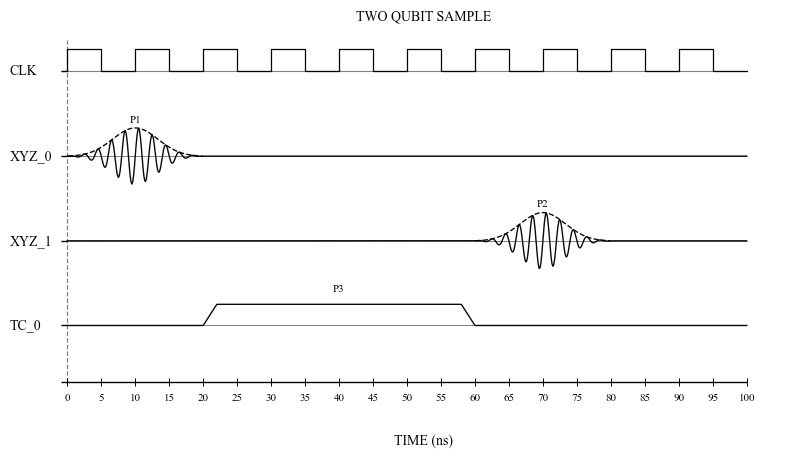

In [6]:
case_name = "two qubit sample"
# f = open("surface_3.txt", "r")
# f = open("surface_3_final.txt","r")
f = open("two_qubit.txt", "r")
qasm_text = f.read()
f.close()

out_dir = Path("runs") / "two qubits"

generate_case(case_name, qasm_text, out_dir)


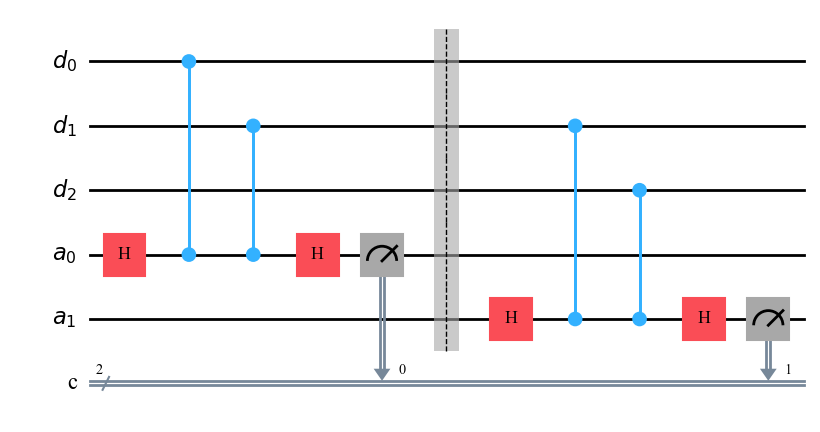

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import circuit_drawer

def circuit_H_CZ_CZ_H() -> QuantumCircuit:
    """
    Your circuit: H on ancilla, CNOT(d1->a), CNOT(d2->a), H on ancilla.
    Qubits: q0=d1, q1=d2, q2=ancilla
    """
    data = QuantumRegister(3, name="d")
    anc  = QuantumRegister(2, name="a")
    c    = ClassicalRegister(2, name="c")

    qc = QuantumCircuit(data, anc, c)

    # H - CX - CX - H on ancilla
    qc.h(anc[0])
    qc.cz(data[0], anc[0])
    qc.cz(data[1], anc[0])
    qc.h(anc[0])

    qc.measure(anc[0],c[0])

    qc.barrier()
    
    qc.h(anc[1])
    qc.cz(data[1], anc[1])
    qc.cz(data[2], anc[1])
    qc.h(anc[1])

    # measure ancilla (optional for drawing)
    qc.measure(anc[1],c[1])
    return qc

qc_bad = circuit_H_CZ_CZ_H()

qc_bad.draw(output="mpl")

In [14]:
from qiskit import qasm3
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import circuit_drawer

# qc = qasm3.load("examples\\surface_3.qasm")
# qc.draw(output="mpl", fold=300)



from qiskit import QuantumCircuit, transpile

# 如果你是 OpenQASM 3
from qiskit.qasm3 import loads as qasm3_loads
from qiskit.qasm3 import dumps as qasm3_dumps

# =========================
# 1) 读取 qasm
# =========================
with open("examples\\surface_3.qasm", "r", encoding="utf-8") as f:
    qasm_text = f.read()

qc = qasm3_loads(qasm_text)

# =========================
# 2) 去掉 barrier
# =========================
qc = qc.remove_final_measurements(inplace=False) if False else qc
# 上面这一句其实没做事，只是提醒不要误删测量。
# 真正去 barrier 用下面的方法：

# qc_no_barrier = QuantumCircuit(*qc.qregs, *qc.cregs, name=qc.name)
# for inst, qargs, cargs in qc.data:
#     if inst.name != "barrier":
#         qc_no_barrier.append(inst, qargs, cargs)

# =========================
# 3) 编译到 cz 基底并优化
# =========================
qc_opt = transpile(
    qc,
    basis_gates=["cz", "h", "x"],
    optimization_level=3,
)

# =========================
# 4) 输出简化后的 qasm3
# =========================
optimized_qasm = qasm3_dumps(qc_opt)

with open("examples\\surface_3_optimized.qasm", "w", encoding="utf-8") as f:
    f.write(optimized_qasm)

print(optimized_qasm)

OPENQASM 3.0;
include "stdgates.inc";
bit[8] m1;
bit[9] m2;
qubit[17] q;
reset q[0];
h q[0];
reset q[1];
reset q[2];
h q[2];
reset q[3];
h q[3];
reset q[4];
h q[4];
reset q[5];
reset q[6];
h q[6];
reset q[7];
reset q[8];
h q[8];
reset q[9];
reset q[10];
reset q[11];
h q[11];
reset q[12];
reset q[13];
h q[13];
reset q[14];
reset q[15];
h q[15];
reset q[16];
barrier q[0], q[1], q[2], q[3], q[4], q[5], q[6], q[7], q[8], q[9], q[10], q[11], q[12], q[13], q[14], q[15], q[16];
h q[1];
h q[7];
h q[12];
h q[16];
barrier q[0], q[1], q[2], q[3], q[4], q[5], q[6], q[7], q[8], q[9], q[10], q[11], q[12], q[13], q[14], q[15], q[16];
h q[2];
cz q[1], q[2];
h q[2];
h q[5];
cz q[6], q[5];
h q[5];
h q[8];
cz q[7], q[8];
h q[8];
h q[10];
cz q[11], q[10];
h q[10];
h q[13];
cz q[12], q[13];
h q[13];
h q[14];
cz q[15], q[14];
h q[14];
barrier q[0], q[1], q[2], q[3], q[4], q[5], q[6], q[7], q[8], q[9], q[10], q[11], q[12], q[13], q[14], q[15], q[16];
h q[0];
cz q[1], q[0];
h q[0];
h q[5];
cz q[2], q[5];
h q[

In [19]:
qc = qasm3.load("examples\\surface_3_optimized.qasm")

from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import RemoveFinalMeasurements

# 只去掉“末尾测量”和它们前面的末尾 barrier

qc_opt = transpile(
    qc,
    basis_gates=["cz", "h"],
    optimization_level=3,
    layout_method="trivial",
    routing_method="none",
)
# pm = PassManager([RemoveFinalMeasurements()])
# qc_unitary = pm.run(qc_opt)
qc_opt.draw(output="mpl", fold=300)

optimized_qasm = qasm3_dumps(qc_opt)

with open("examples\\surface_3_final.qasm", "w", encoding="utf-8") as f:
    f.write(optimized_qasm)

print(optimized_qasm)

OPENQASM 3.0;
include "stdgates.inc";
bit[8] m1;
bit[9] m2;
qubit[17] q;
reset q[0];
reset q[1];
h q[1];
reset q[2];
cz q[1], q[2];
cz q[1], q[0];
h q[0];
h q[1];
h q[2];
reset q[3];
reset q[4];
h q[4];
reset q[5];
h q[5];
reset q[6];
h q[6];
cz q[6], q[5];
cz q[2], q[5];
h q[2];
h q[6];
reset q[7];
h q[7];
reset q[8];
cz q[7], q[8];
cz q[7], q[6];
cz q[7], q[3];
h q[3];
cz q[7], q[2];
h q[7];
h q[8];
reset q[9];
h q[9];
reset q[10];
h q[10];
reset q[11];
h q[11];
cz q[11], q[10];
cz q[4], q[10];
cz q[4], q[5];
cz q[0], q[5];
h q[0];
h q[4];
h q[5];
h q[10];
h q[11];
reset q[12];
h q[12];
reset q[13];
cz q[12], q[13];
cz q[12], q[11];
cz q[12], q[6];
h q[6];
cz q[12], q[4];
h q[12];
h q[13];
reset q[14];
h q[14];
reset q[15];
h q[15];
cz q[15], q[14];
cz q[8], q[14];
cz q[8], q[9];
cz q[3], q[9];
h q[3];
h q[8];
h q[9];
cz q[13], q[14];
cz q[6], q[14];
h q[6];
h q[13];
h q[14];
h q[15];
reset q[16];
h q[16];
cz q[16], q[15];
cz q[16], q[13];
h q[16];
barrier q[0], q[1], q[2], q[3], q[4

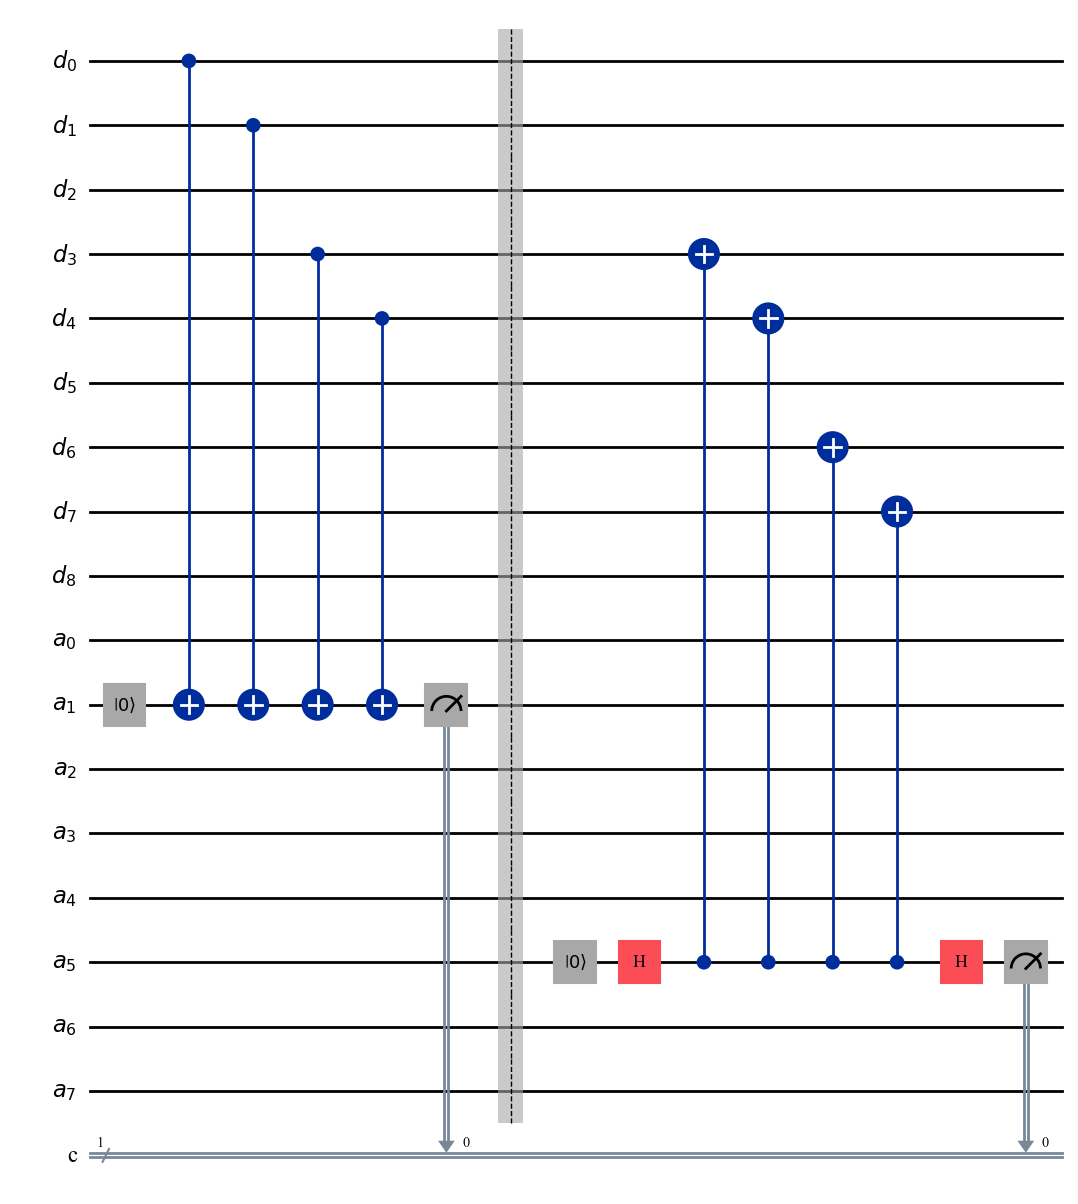

In [39]:
data = QuantumRegister(9, name="d")
anc  = QuantumRegister(8, name="a")
c    = ClassicalRegister(1, name="c")

qc = QuantumCircuit(data, anc, c)

qc.reset(anc[1])
for i in [0,1,3,4]:
    qc.cx(data[i], anc[1])

qc.measure(anc[1],c[0])

qc.barrier()

qc.reset(anc[5])
qc.h(anc[5])
for i in [3,4,6,7]:
    qc.cx(anc[5], data[i])
qc.h(anc[5])
qc.measure(anc[5],c[0])

qc.draw(output='mpl')